# M_03 — CRH par ZONE + robuste

Évolution du CRH sur nœuds. Deux ajouts par rapport à la version à poids global :

**1. Robustesse (unilatérale).** La fiabilité d'une source n'est plus estimée par la moyenne
simple de ses distances au consensus (sensible aux quelques jonctions « rivière » à 40–95 m),
mais par une **moyenne robuste de Tukey** : les distances anormalement grandes sont fortement
dépondérées. Unilatérale = on ne pénalise QUE les grandes distances (on garde plein poids aux
petites, ex. les points IGN identiques de GEOFLA, qui sont une vraie info).

**2. Poids par zone.** Une source peut être bonne ici et mauvaise là (Cadastre : excellent en
ville, mauvais sur les rivières). On découpe l'espace en zones (k-means sur les positions des
nœuds) et on estime **un jeu de poids par zone**. Dans une zone propre le Cadastre a un poids
élevé ; dans une zone rivière, faible — ce qu'un poids global unique ne peut pas représenter.

La cohérence topologique n'est pas affectée : chaque nœud reçoit toujours UNE position fusionnée
(le graphe nœud/arc est inchangé), seuls les poids qui servent à la calculer varient par zone.

Entrée : `match_nodes.csv`. Sorties : `nodes_fused.gpkg`, `crh_weights_zonal.csv`.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from collections import defaultdict

MATCHING_DIR = r'C:/Users/rocrom/Resolving-Conflicts-in-Heterogeneous-Data--CRH_Framework/final'
N_ZONES   = 10      # nb de zones k-means (vise ~10-15 nœuds/zone pour la source la plus rare)
C_TUKEY   = 3.5    # constante de Tukey : distance > médiane + C_TUKEY*MAD => poids ~0
MIN_CELL  = 6      # mini de nœuds (zone,source) pour estimer localement ; sinon repli global

## 1. Chargement + clustering des nœuds homologues (union-find)

In [2]:
match_nodes = pd.read_csv(f'{MATCHING_DIR}/match_nodes.csv')
parent, pos = {}, {}
def find(k):
    parent.setdefault(k, k)
    while parent[k] != k:
        parent[k] = parent[parent[k]]; k = parent[k]
    return k
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: parent[rb] = ra
for _, r in match_nodes.iterrows():
    a = (r.source_a, int(r.node_a)); b = (r.source_b, int(r.node_b))
    pos[a] = np.array([r.x_a, r.y_a]); pos[b] = np.array([r.x_b, r.y_b])
    union(a, b)
clusters = defaultdict(dict)
for keynode in pos:
    clusters[find(keynode)][keynode[0]] = pos[keynode]
data = {f'J{i}': obs for i, obs in enumerate(clusters.values())}
sources = sorted({s for obs in data.values() for s in obs})
print(f'Clusters : {len(data)}   Sources : {sources}')

Clusters : 983   Sources : ['bdtopo', 'cadastre', 'geofla']


## 2. Découpage en zones (k-means)

Chaque cluster est positionné en son **centroïde** (moyenne des positions des sources qui
l'observent), puis k-means répartit les clusters en `N_ZONES` zones contiguës. k-means minimal
en numpy (aucune dépendance externe).

In [3]:
def kmeans(X, k, n_iter=100, seed=0):
    rng = np.random.default_rng(seed)
    C = X[rng.choice(len(X), k, replace=False)]
    for _ in range(n_iter):
        lab = np.argmin(((X[:, None, :] - C[None, :, :])**2).sum(2), axis=1)
        newC = np.array([X[lab == j].mean(0) if (lab == j).any() else C[j] for j in range(k)])
        if np.allclose(newC, C): C = newC; break
        C = newC
    return lab, C

keys = list(data.keys())
centro = np.array([np.mean([data[k][s] for s in data[k]], axis=0) for k in keys])
lab, centres = kmeans(centro, N_ZONES, seed=0)
zone_of = {keys[i]: int(lab[i]) for i in range(len(keys))}

# effectifs par (zone, source) : controle de viabilite
print('Effectifs par zone :')
for z in range(N_ZONES):
    ks = [k for k in keys if zone_of[k] == z]
    cnt = {s: sum(1 for k in ks if s in data[k]) for s in sources}
    faibles = [s for s in sources if cnt[s] < MIN_CELL]
    flag = f'  ⚠ repli global pour {faibles}' if faibles else ''
    print(f'  zone {z} : {len(ks):2d} nœuds | ' + '  '.join(f'{s}={cnt[s]}' for s in sources) + flag)

Effectifs par zone :
  zone 0 : 121 nœuds | bdtopo=121  cadastre=98  geofla=121
  zone 1 : 112 nœuds | bdtopo=112  cadastre=93  geofla=111
  zone 2 : 68 nœuds | bdtopo=68  cadastre=57  geofla=67
  zone 3 : 117 nœuds | bdtopo=117  cadastre=91  geofla=117
  zone 4 : 81 nœuds | bdtopo=81  cadastre=56  geofla=81
  zone 5 : 149 nœuds | bdtopo=149  cadastre=112  geofla=147
  zone 6 : 100 nœuds | bdtopo=100  cadastre=87  geofla=100
  zone 7 : 62 nœuds | bdtopo=62  cadastre=54  geofla=60
  zone 8 : 118 nœuds | bdtopo=118  cadastre=96  geofla=116
  zone 9 : 55 nœuds | bdtopo=55  cadastre=45  geofla=55


## 3. CRH robuste par zone

- **vérité** d'un cluster = moyenne pondérée par les poids **de sa zone** ;
- **fiabilité** d'une source dans une zone = `1 / moyenne_robuste(distances au consensus)` ;
- si trop peu de nœuds dans une cellule (zone,source) : **repli** sur la fiabilité globale ;
- poids **normalisés par zone** (somme = 1 dans chaque zone).

In [4]:
# ============================================================
#  CRH par zone + robuste + PARTIAL POOLING (regularisation)
#  Remplace la cellule de l'algorithme dans M_03_crh_zonal.ipynb.
#  Ajoute KAPPA : chaque cellule (zone,source) melange son estimation locale
#  avec l'estimation globale, en proportion de son nombre de noeuds.
#  -> empeche le collapse des zones peu peuplees, garde le signal des zones riches.
# ============================================================

KAPPA = 5   # pseudo-comptes du global. 0 = pur local (instable a petite echelle) ;
               # grand = tire fortement vers le global. ~10 = bon compromis a ton echelle.


def robust_mean(ds, c=C_TUKEY):
    """Moyenne robuste unilaterale : depondere les distances anormalement GRANDES."""
    a = np.asarray(ds, float)
    if len(a) == 0:
        return np.inf
    med = np.median(a); mad = np.median(np.abs(a - med)) * 1.4826
    if mad < 1e-9:
        return float(a.mean())
    u = np.maximum(0.0, (a - med) / (c * mad))     # petites distances intactes
    tw = np.where(u < 1, (1 - u**2)**2, 0.0)
    return float(np.sum(tw * a) / np.sum(tw)) if tw.sum() > 1e-9 else float(med)


def crh_zonal(data, sources, zone_of, n_zones, c_tukey=C_TUKEY, kappa=KAPPA,
              max_iter=300, eps=1e-7, verbose=True):
    Z = range(n_zones)
    w = {z: {s: 1/len(sources) for s in sources} for z in Z}
    truth, history = {}, []
    for it in range(1, max_iter+1):
        # verite = moyenne ponderee par les poids DE LA ZONE du cluster
        for k, obs in data.items():
            z = zone_of[k]
            num = sum(w[z][s]*obs[s] for s in obs); den = sum(w[z][s] for s in obs)
            truth[k] = num/den
        # distances par cellule (zone,source) et globales par source
        dist_zs = defaultdict(list); dist_g = defaultdict(list)
        for k, obs in data.items():
            z = zone_of[k]
            for s in obs:
                d = float(np.linalg.norm(obs[s]-truth[k]))
                dist_zs[(z, s)].append(d); dist_g[s].append(d)
        # erreur robuste globale par source (la cible du shrinkage)
        m_glob = {s: robust_mean(dist_g[s], c_tukey) for s in sources}
        nw = {}
        for z in Z:
            rel = {}
            for s in sources:
                ds = dist_zs.get((z, s), []); n = len(ds)
                if n == 0:
                    m_reg = m_glob[s]                      # source absente : global
                else:
                    m_loc = robust_mean(ds, c_tukey)
                    m_reg = (n*m_loc + kappa*m_glob[s]) / (n + kappa)   # PARTIAL POOLING
                rel[s] = 1/max(m_reg, 1e-9)
            tot = sum(rel.values()); nw[z] = {s: rel[s]/tot for s in sources}
        delta = max(abs(nw[z][s]-w[z][s]) for z in Z for s in sources)
        w = nw; history.append(delta)
        if verbose and (it <= 5 or delta < eps):
            print(f'it{it:3d} | delta={delta:.1e}')
        if delta < eps:
            break
    return w, truth, history


weights, truth, history = crh_zonal(data, sources, zone_of, N_ZONES)

# Controle : ecart-type de chaque source entre zones.
# Une source uniforme (GEOFLA) doit avoir un faible ecart-type -> estimation stable.
print('\nStabilite des poids entre zones (ecart-type ; faible = stable) :')
for s in sources:
    vals = [weights[z][s] for z in range(N_ZONES)]
    print(f'  {s:9s} : moyenne={np.mean(vals):.3f}  ecart-type={np.std(vals):.3f}')

it  1 | delta=1.3e-01
it  2 | delta=6.9e-02
it  3 | delta=5.7e-02
it  4 | delta=4.6e-02
it  5 | delta=2.8e-02
it 37 | delta=7.5e-08

Stabilite des poids entre zones (ecart-type ; faible = stable) :
  bdtopo    : moyenne=0.514  ecart-type=0.057
  cadastre  : moyenne=0.255  ecart-type=0.100
  geofla    : moyenne=0.231  ecart-type=0.108


## 4. Poids par zone

In [5]:
print(f"{'zone':>5} | " + '  '.join(f'{s:>9}' for s in sources) + '   | nœuds')
for z in range(N_ZONES):
    ks = [k for k in data if zone_of[k] == z]
    print(f'{z:>5} | ' + '  '.join(f'{weights[z][s]:>9.3f}' for s in sources) + f'   | {len(ks)}')
print('\n(chaque ligne somme à 1 : ce sont les poids RELATIFS des sources dans la zone)')

 zone |    bdtopo   cadastre     geofla   | nœuds
    0 |     0.527      0.301      0.172   | 121
    1 |     0.547      0.318      0.135   | 112
    2 |     0.518      0.067      0.415   | 68
    3 |     0.473      0.171      0.356   | 117
    4 |     0.504      0.272      0.224   | 81
    5 |     0.487      0.125      0.388   | 149
    6 |     0.442      0.348      0.211   | 100
    7 |     0.462      0.363      0.176   | 62
    8 |     0.524      0.367      0.109   | 118
    9 |     0.658      0.220      0.122   | 55

(chaque ligne somme à 1 : ce sont les poids RELATIFS des sources dans la zone)


## 5. Carte des zones + poids du Cadastre

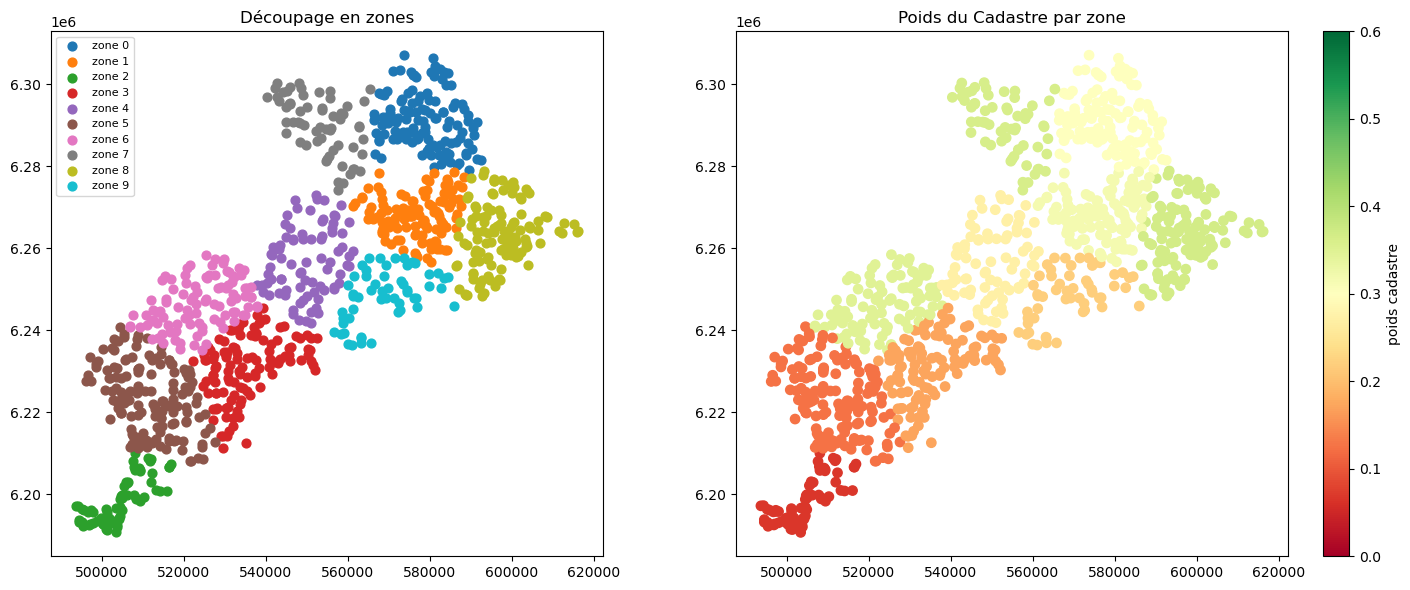

In [6]:
keys = list(data.keys())
XY = np.array([np.mean([data[k][s] for s in data[k]], axis=0) for k in keys])
zc = np.array([zone_of[k] for k in keys])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for z in range(N_ZONES):
    m = zc == z
    ax1.scatter(XY[m, 0], XY[m, 1], s=40, label=f'zone {z}')
ax1.set_title('Découpage en zones'); ax1.legend(fontsize=8); ax1.set_aspect('equal')
# couleur = poids du cadastre dans la zone du noeud
wc = np.array([weights[zone_of[k]].get('cadastre', np.nan) for k in keys])
sc = ax2.scatter(XY[:, 0], XY[:, 1], c=wc, s=45, cmap='RdYlGn', vmin=0, vmax=0.6)
ax2.set_title('Poids du Cadastre par zone'); ax2.set_aspect('equal')
plt.colorbar(sc, ax=ax2, label='poids cadastre')
plt.tight_layout(); plt.show()

## 6. Sortie — nœuds fusionnés + poids par zone

In [7]:
rows = []
for k, obs in data.items():
    t = truth[k]
    rows.append({'cluster': k, 'zone': zone_of[k], 'n_sources': len(obs),
                 'x_fusion': round(float(t[0]), 3), 'y_fusion': round(float(t[1]), 3),
                 'geometry': Point(float(t[0]), float(t[1]))})
nodes_fused = gpd.GeoDataFrame(rows, crs='EPSG:2154')
nodes_fused.to_file(f'{MATCHING_DIR}/nodes_fused.gpkg', driver='GPKG')
nodes_fused.drop(columns='geometry').to_csv(f'{MATCHING_DIR}/nodes_fused.csv', index=False)

wz = [{'zone': z, **{s: round(weights[z][s], 4) for s in sources}} for z in range(N_ZONES)]
pd.DataFrame(wz).to_csv(f'{MATCHING_DIR}/crh_weights_zonal.csv', index=False)

print('Sauvegardé : nodes_fused.gpkg/csv, crh_weights_zonal.csv')
print(f'{len(nodes_fused)} nœuds fusionnés sur {N_ZONES} zones')

Sauvegardé : nodes_fused.gpkg/csv, crh_weights_zonal.csv
983 nœuds fusionnés sur 10 zones


## 7. Bilan

Chaque source a maintenant **un poids par zone**, estimé de façon **robuste** (insensible aux
jonctions « rivière »). Le Cadastre obtient un poids élevé là où il est précis et faible là où
il diverge, au lieu d'un compromis global médiocre. Les positions fusionnées (`nodes_fused`)
alimentent M_04 comme avant — la topologie est inchangée.

**Réglages.** `N_ZONES` : viser ~10–15 nœuds/zone pour la source la plus rare (sinon repli
global, signalé en section 2). `C_TUKEY` : plus petit = plus agressif sur les outliers.

**À l'échelle D031.** Le k-means se remplacera avantageusement par un **découpage métier**
(blocs d'en-matching alignés, ou bassins versants) — plus de zones, mieux peuplées, et
interprétables (« le Cadastre est faible dans le bassin de l'Ariège »).